In [144]:
# 需要安装的包
import xarray as xr
import pandas as pd
import numpy as np
from typing import Optional, Dict, Any, List
import json

In [8]:
df = xr.open_dataset(r"D:/weather_pre/PRE_1h_2024010100.nc", engine="netcdf4")

<xarray.Dataset> Size: 20MB
Dimensions:    (latitude: 1701, longitude: 3001)
Coordinates:
  * latitude   (latitude) float32 7kB 37.0 37.01 37.02 ... 53.98 53.99 54.0
  * longitude  (longitude) float32 12kB 97.0 97.01 97.02 ... 127.0 127.0 127.0
Data variables:
    PRE_1h     (latitude, longitude) float32 20MB ...


In [15]:
class NetCDFToJSON:
    """
    将 NetCDF 文件解析为多变量 JSON（与达卯气象接口格式一致）
    """

    def __init__(self, file_path: str):
        self.ds = xr.open_dataset(file_path)

    # -------------------
    # 自动识别所有变量单位
    # -------------------
    def extract_units(self) -> Dict[str, str]:
        units = {}
        for name, var in self.ds.variables.items():
            units[name] = var.attrs.get("units", None)
        return units

    # -------------------
    # 整体解析为 DataFrame
    # -------------------
    def to_dataframe(self) -> pd.DataFrame:
        """
        将整个数据集（所有变量 + 坐标）展开为二维表
        """
        df = self.ds.to_dataframe().reset_index()
        return df

    # -------------------
    # 解析 JSON（核心）
    # -------------------
    def to_json_records(self) -> List[Dict[str, Any]]:
        df = self.to_dataframe()

        # 将 numpy 转 Python 类型，避免 JSON 序列化失败
        df = df.where(pd.notnull(df), None)

        # 按行输出 JSON（每行是一个时刻+格点）
        json_list = df.to_dict(orient="records")
        return json_list

    # -------------------
    # 返回 {data: [...], units: {...}} 结构
    # -------------------
    def to_api_format(self) -> Dict[str, Any]:
        """
        生成类似达卯接口输出的数据结构：
        {
            "data": [... 每条记录 ...],
            "units": {... 每个变量的单位 ...}
        }
        """
        return {
            "data": self.to_json_records(),
            "units": self.extract_units()
        }


In [21]:
parser = NetCDFToJSON(r"D:/weather_pre/PRE_1h_2024010100.nc")
result = parser.to_api_format()
with open("output.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print("已保存 output.json，可以完整查看解析结果")

已保存 output.json，可以完整查看解析结果


In [29]:
from pymongo import MongoClient
from urllib.parse import quote_plus
import pandas as pd

In [201]:
class WeatherMongoClient:
    def __init__(
        self,
        host="123.60.41.219",
        port=27017,
        database="weather",
        username="weather_app",
        password="weather!@#123",
        timeout_ms=5000
    ):
        username = quote_plus(username)
        password = quote_plus(password)

        # ✅ 关键修复：不再使用 authSource=admin
        self.uri = (
            f"mongodb://{username}:{password}"
            f"@{host}:{port}/{database}"
        )

        self.client = MongoClient(
            self.uri,
            serverSelectionTimeoutMS=timeout_ms,
            connectTimeoutMS=timeout_ms,
            socketTimeoutMS=timeout_ms
        )

        self.db = self.client[database]

    def list_collections(self):
        return self.db.list_collection_names()

    def find_to_df(self, collection, query=None, projection=None):
        if query is None:
            query = {}

        data = list(self.db[collection].find(query, projection))
        if not data:
            return pd.DataFrame()

        df = pd.DataFrame(data)
        if "_id" in df.columns:
            df.drop(columns=["_id"], inplace=True)

        return df

    def find_to_json(self, collection, query=None, projection=None):
        if query is None:
            query = {}

        return list(self.db[collection].find(query, projection or {"_id": 0}))

In [202]:
mongo = WeatherMongoClient()
print(mongo.list_collections())

['t_sync_meta', 'forecast_lon_lat_data', 'forecast_data1', 'real_data_v2', 'real_data', 'forecast_data', 'area_data']


In [32]:
data = list(
    mongo.db["real_data"]
    .find({}, {"_id": 0})
    .limit(1)
)
print(data)


[{'rh': 70.02533721923828, 't_avg': -8.279999732971191, 'ssrd': 0.0, 'lon': 109.02, 'lat': 38.58, 'datatime': 2024010100, '_class': 'com.damao.weather.pojo.entity.RealDataEntity'}]


In [33]:
data = list(
    mongo.db["forecast_data"]
    .find({}, {"_id": 0})
    .limit(1)
)
print(data)

[{'areacode': '101080101', 'prec': 0.0, 'rh': 43.4, 'ssrd': 44.2, 't_avg': -11.8, 'wns_grd': '4', 'wd': 36.1, 'ws': 7.3, 'lon': 111.75, 'lat': 40.85, 'datatime': '2025-12-08 09:00:00', 'collect_time': '2025-12-07 09:00:00', '_class': 'com.damao.weather.pojo.entity.ForecastDataEntity'}]


In [207]:
data = list(
    mongo.db["area_data_v2"]
    .find({}, {"_id": 0})
    .limit(1)
)
print(data)

[]


In [23]:
data = list(mongo.db["area_data"].find(
    {"city": "通辽市"},
    {"areacode": 1, "_id": 0}
))
print(data)

[{'areacode': '101080501'}, {'areacode': '101080503'}, {'areacode': '101080504'}, {'areacode': '101080506'}, {'areacode': '101080507'}, {'areacode': '101080508'}, {'areacode': '101080509'}, {'areacode': '101080510'}, {'areacode': '101080512'}]


In [35]:
mongo.db["forecast_data"].index_information()

{'_id_': {'v': 2, 'key': [('_id', 1)]}}

In [358]:
from pymongo import MongoClient
from urllib.parse import quote_plus

username = quote_plus("weather_app")
password = quote_plus("weather!@#123")

host = "123.60.41.219"
port = 27017
db_name = "weather"

uri = f"mongodb://{username}:{password}@{host}:{port}/{db_name}"

client_index = MongoClient(
    uri,
    socketTimeoutMS=10 * 60 * 1000,
    connectTimeoutMS=60 * 1000,
    serverSelectionTimeoutMS=60 * 1000
)

db = client_index[db_name]

print("✅ MongoDB 认证连接成功")


✅ MongoDB 认证连接成功


In [209]:

# ===========================================
result = db["real_data_v2"].create_index(
    [("lat", 1), ("lon", 1), ("datatime", 1)],
    name="idx_lat_lon_time"
)
print("索引创建完成：", result)
# 查看索引信息
print(db["real_data_v2"].index_information())


索引创建完成： idx_lat_lon_time
{'_id_': {'v': 2, 'key': [('_id', 1)]}, 'datatime_text_lat_text': {'v': 2, 'key': [('_fts', 'text'), ('_ftsx', 1)], 'weights': SON([('datatime', 1), ('lat', 1)]), 'default_language': 'english', 'language_override': 'language', 'textIndexVersion': 3}, 'idx_lat_lon_time': {'v': 2, 'key': [('lat', 1), ('lon', 1), ('datatime', 1)]}}


In [211]:
db.real_data_v2.find(
    {
        "lat": 40.7,
        "lon": 113.2,
        "datatime": {"$gte": 2024050100, "$lte": 2024050123}
    }
).explain()

{'explainVersion': '1',
 'queryPlanner': {'namespace': 'weather.real_data_v2',
  'parsedQuery': {'$and': [{'lat': {'$eq': 40.7}},
    {'lon': {'$eq': 113.2}},
    {'datatime': {'$lte': 2024050123}},
    {'datatime': {'$gte': 2024050100}}]},
  'indexFilterSet': False,
  'queryHash': '8F126C1F',
  'planCacheShapeHash': '8F126C1F',
  'planCacheKey': '501CE9A2',
  'optimizationTimeMillis': 0,
  'maxIndexedOrSolutionsReached': False,
  'maxIndexedAndSolutionsReached': False,
  'maxScansToExplodeReached': False,
  'prunedSimilarIndexes': False,
  'winningPlan': {'isCached': False,
   'stage': 'FETCH',
   'inputStage': {'stage': 'IXSCAN',
    'keyPattern': {'lat': 1, 'lon': 1, 'datatime': 1},
    'indexName': 'idx_lat_lon_time',
    'isMultiKey': False,
    'multiKeyPaths': {'lat': [], 'lon': [], 'datatime': []},
    'isUnique': False,
    'isSparse': False,
    'isPartial': False,
    'indexVersion': 2,
    'direction': 'forward',
    'indexBounds': {'lat': ['[40.7, 40.7]'],
     'lon': ['[1

In [359]:
result_weighet = db["real_data_weight"].create_index([("datatime", 1)],
    name="idx_time")
print("索引创建完成：", result_weighet)
# 查看索引信息
print(db["real_data_weight"].index_information())

OperationFailure: Index already exists with a different name: datatime_1, full error: {'ok': 0.0, 'errmsg': 'Index already exists with a different name: datatime_1', 'code': 85, 'codeName': 'IndexOptionsConflict'}

In [360]:
db["real_data_weight"].index_information()



{'_id_': {'v': 2, 'key': [('_id', 1)]},
 'datatime_1': {'v': 2, 'key': [('datatime', 1)]}}

In [46]:
print("🚀 创建 uk_area_areacode ...")

res = db["area_data"].create_index(
    [("areacode", 1)],
    name="uk_area_areacode",
    unique=True
)
print("✅ 已提交索引：", res)


🚀 创建 uk_area_areacode ...
✅ 已提交索引： uk_area_areacode


In [47]:
print("🚀 创建 idx_area_admin_chain ...")

res = db["area_data"].create_index(
    [("province_geocode", 1), ("city_geocode", 1), ("district_geocode", 1)],
    name="idx_area_admin_chain",
    background=True
)
print("✅ 已提交索引：", res)


🚀 创建 idx_area_admin_chain ...
✅ 已提交索引： idx_area_admin_chain


In [241]:
# 标准获取函数

from pymongo import MongoClient
from urllib.parse import quote_plus
import pandas as pd


class WeatherMongoReader:

    def __init__(
        self,
        host="123.60.41.219",
        port=27017,
        db_name="weather",
        username="weather_app",
        password="weather!@#123",
    ):
        user = quote_plus(username)
        pwd = quote_plus(password)

        uri = (
            f"mongodb://{user}:{pwd}@{host}:{port}/{db_name}"
            f"?authSource={db_name}"
        )

        self.client = MongoClient(
            uri,
            serverSelectionTimeoutMS=30000,
            socketTimeoutMS=300000,
            connectTimeoutMS=30000,
        )
        self.db = self.client[db_name]

        # 启动时校验连接
        self.db.list_collection_names()
        print("MongoDB 连接成功")

    # =========================
    # 格点实况读取（real_data）
    # =========================
    def get_real_by_point_and_time(
        self,
        lat: float,
        lon: float,
        start_time: int,
        end_time: int,
        limit: int = 5000,
    ) -> pd.DataFrame:
        """
        走索引：idx_real_lat_lon_time
        查询：单格点 + 时间范围
        """

        query = {
            "lat": lat,
            "lon": lon,
            "datatime": {"$gte": start_time, "$lte": end_time},
        }

        cursor = (
            self.db["real_data"]
            .find(query, {"_id": 0})
            .sort("datatime", 1)
            .limit(limit)
        )

        data = list(cursor)
        return pd.DataFrame(data)
    #==========================
    # 格点实况读取（real_data_v2）
    # =========================
    def get_real_by_point_and_time_v2(
        self,
        lat: float,
        lon: float,
        start_time: int,
        end_time: int,
        limit: int = 5000,
    ) -> pd.DataFrame:
        """
        走索引：idx_real_lat_lon_time
        查询：单格点 + 时间范围
        """

        query = {
            "lat": lat,
            "lon": lon,
            "datatime": {"$gte": start_time, "$lte": end_time},
        }

        cursor = (
            self.db["real_data_v2"]
            .find(query, {"_id": 0})
            .sort("datatime", 1)
            .limit(limit)
        )

        data = list(cursor)
        return pd.DataFrame(data)



    # =========================
    # 城镇预报读取（forecast_data）
    # =========================
    def get_forecast_by_areacode_and_time(
        self,
        areacode: str,
        start_time: str,
        end_time: str,
        limit: int = 5000,
    ) -> pd.DataFrame:
        """
        走索引：idx_forecast_areacode_time
        查询：单城镇 + 时间范围
        """

        query = {
            "areacode": areacode,
            "datatime": {"$gte": start_time, "$lte": end_time},
        }

        cursor = (
            self.db["forecast_data"]
            .find(query, {"_id": 0})
            .sort("datatime", 1)
            .limit(limit)
        )

        data = list(cursor)
        return pd.DataFrame(data)

    # =========================
    # 地市 / 区县 → 城镇编码映射（area_data）
    # =========================
    def get_areacodes_by_city(
        self,
        city_geocode: str,
    ):
        """
        走索引：idx_area_admin_chain
        查询：某地市下所有城镇
        """

        cursor = self.db["area_data"].find(
            {"city_geocode": city_geocode},
            {"_id": 0, "areacode": 1, "district": 1},
        )

        data = list(cursor)
        return pd.DataFrame(data)

    # =========================
    # 多城镇批量预报（工程级聚合场景）
    # =========================
    def get_forecast_by_multi_areacode_and_time(
        self,
        areacode_list: list,
        start_time: str,
        end_time: str,
        limit: int = 20000,
    ) -> pd.DataFrame:
        """
        走索引：idx_forecast_areacode_time
        查询：多个城镇 + 同一时间范围
        """

        query = {
            "areacode": {"$in": areacode_list},
            "datatime": {"$gte": start_time, "$lte": end_time},
        }

        cursor = (
            self.db["forecast_data"]
            .find(query, {"_id": 0})
            .sort([("areacode", 1), ("datatime", 1)])
            .limit(limit)
        )

        data = list(cursor)
        return pd.DataFrame(data)


In [51]:
# 获取示例
mongo = WeatherMongoReader()
df_forecast = mongo.get_forecast_by_areacode_and_time(
    areacode="101080101",   # 呼和浩特
    start_time="2025-12-10 10:00:00",
    end_time="2025-12-11 01:00:00",
)
print(df_forecast)


ERROR! Session/line number was not unique in database. History logging moved to new session 32
✅ MongoDB 连接成功


In [198]:
areacodes = ["101080101", "101080201", "101080401", "101080405"]

df_multi = mongo.get_forecast_by_multi_areacode_and_time(
    areacode_list=areacodes,
    start_time="2025-12-10 10:00:00",
    end_time="2025-12-11 01:00:00",
)


In [333]:
df = pd.read_excel("内蒙古城市编码表.xlsx")
print(df['city'].unique())
city_names = ['呼和浩特市','包头市','乌海市','鄂尔多斯市','巴彦淖尔市','乌兰察布市','阿拉善盟']
df = df[df['city'].isin(city_names)]

['呼和浩特市' '包头市' '乌海市' '赤峰市' '通辽市' '鄂尔多斯市' '呼伦贝尔市' '巴彦淖尔市' '乌兰察布市' '兴安盟'
 '锡林郭勒盟' '阿拉善盟']


In [334]:
print(df['city'].unique())
print(df.columns)

['呼和浩特市' '包头市' '乌海市' '鄂尔多斯市' '巴彦淖尔市' '乌兰察布市' '阿拉善盟']
Index(['areacode', 'province_geocode', 'province', 'city_geocode', 'city',
       'district_geocode', 'district', 'eng', 'pinyin', 'lon', 'lat'],
      dtype='object')


In [335]:
df_ = df[['areacode','lat','lon']]
df_[['lat','lon']] = df_[['lat','lon']].astype(float)
df_[['lat','lon']] = df_[['lat','lon']].round(1)
# print(df_.head())

C:\Users\18333\AppData\Local\Temp\ipykernel_29788\3327076227.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_[['lat','lon']] = df_[['lat','lon']].astype(float)
C:\Users\18333\AppData\Local\Temp\ipykernel_29788\3327076227.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_[['lat','lon']] = df_[['lat','lon']].round(1)


In [251]:
def get_real_for_points(
    mongo: WeatherMongoReader,
    df_points: pd.DataFrame,
    start_time: int,
    end_time: int,
    limit_per_point: int = 5000,
) -> pd.DataFrame:

    all_results = []

    for _, row in df_points.iterrows():
        lat = float(row["lat"])
        lon = float(row["lon"])
        areacode = row.get("areacode", None)

        df_single = mongo.get_real_by_point_and_time_v2(
            lat=lat,
            lon=lon,
            start_time=start_time,
            end_time=end_time,
            limit=limit_per_point,
        )

        if df_single.empty:
            continue

        df_single["lat"] = lat
        df_single["lon"] = lon
        if areacode is not None:
            df_single["areacode"] = areacode

        all_results.append(df_single)

    if all_results:
        return pd.concat(all_results, ignore_index=True)
    else:
        return pd.DataFrame()


In [341]:
mongo = WeatherMongoReader()
df_real = get_real_for_points(
    mongo=mongo,
    df_points=df_,
    start_time=2024010100,
    end_time=2024022823,
)
# df_real_2 = get_real_for_points(
#     mongo=mongo,
#     df_points=df_,
#     start_time=2024060100,
#     end_time=2024063023,
# )

# # print(df_real.head())
print(df_real.shape)
# print(df_real_2.shape)

MongoDB 连接成功
(64322, 10)


In [342]:
df_real_2 = get_real_for_points(
    mongo=mongo,
    df_points=df_,
    start_time=2024060100,
    end_time=2024083123,
)
print(df_real_2.shape)

(290000, 10)


In [343]:
df_real = pd.concat([df_real, df_real_2], ignore_index=True)
print(df_real.shape)


(354322, 10)


In [151]:
import os
import pandas as pd
import re

def read_measured_folder(folder_path):
    all_data = []

    # 正则：识别实测值列，如 “01月01日实测值”、“实测值01-01”
    pattern = re.compile(r".*实测值.*")

    for file in os.listdir(folder_path):
        if not file.endswith(".xlsx"):
            continue

        # =============== 1. 从文件名提取日期 ===============
        date_str = os.path.splitext(file)[0]    # "2024-01-01"
        try:
            base_date = pd.to_datetime(date_str)
        except:
            print(f"⚠ 文件名无法解析日期：{file}")
            continue

        file_path = os.path.join(folder_path, file)
        df = pd.read_excel(file_path)

        # =============== 2. 查找时刻列 ===============
        # 允许列名如：时刻 / 时间 / hour / 时段 / 具体某列
        time_col_candidates = [c for c in df.columns if "时" in c or "间" in c or "time" in c.lower()]
        if len(time_col_candidates) == 0:
            # 默认第1列是时刻
            time_col = df.columns[0]
        else:
            time_col = time_col_candidates[0]

        # =============== 3. 自动识别“实测值”列 ===============
        measured_cols = [c for c in df.columns if pattern.match(c)]
        if len(measured_cols) == 0:
            print(f"⚠ 未找到实测值列：{file}")
            continue

        measured_col = measured_cols[0]

        # =============== 4. 生成完整时间戳 ===============
        df["datetime"] = df[time_col].apply(lambda t: pd.to_datetime(f"{date_str} {t}"))

        # =============== 5. 只保留关键字段 ===============
        df_result = df[["datetime", measured_col]].rename(columns={measured_col: "value"})

        all_data.append(df_result)

    # =============== 6. 合并所有文件 ===============
    if len(all_data) == 0:
        return pd.DataFrame(columns=["datetime", "value"])

    final_df = pd.concat(all_data).sort_values("datetime").reset_index(drop=True)
    return final_df


In [257]:
folder = r"D:\PythonProject\algorithm\resources (2)\统调负荷预测及实测\2024"
df_load = read_measured_folder(folder)


In [344]:
dt = df_real["datatime"].astype(str).str.zfill(10)
df_real["datatime"] = pd.to_datetime(dt, format="%Y%m%d%H")
# df_real["datatime"] = pd.to_datetime(df_real["datatime"].astype(str), format="%Y%m%d%H")
df_load['datetime'] = pd.to_datetime(df_load['datetime'])

In [345]:
df_real = df_real.dropna(how="any")
df_load = df_load.dropna(how="any")
df_merger = df_real.merge(df_load, left_on="datatime", right_on="datetime")

In [260]:
print(df_merger)

               rh      t_avg        ssrd    lon   lat            datatime  \
0       77.444206  -9.785000    0.000000  111.7  40.8 2024-01-01 00:00:00   
1       79.110512 -10.530000    0.000000  111.7  40.8 2024-01-01 01:00:00   
2       77.110512 -10.740000    0.000000  111.7  40.8 2024-01-01 02:00:00   
3       70.665222 -11.150000    0.000000  111.7  40.8 2024-01-01 03:00:00   
4       72.554710  -9.735000    0.000000  111.7  40.8 2024-01-01 04:00:00   
...           ...        ...         ...    ...   ...                 ...   
104033  31.482590  16.344999    0.000000  105.1  39.6 2024-06-23 03:00:00   
104034  36.103859  15.270000    0.000000  105.1  39.6 2024-06-23 04:00:00   
104035  48.421940  13.535000    0.000000  105.1  39.6 2024-06-23 05:00:00   
104036  47.870338  13.415000   21.184351  105.1  39.6 2024-06-23 06:00:00   
104037  47.551514  15.215000  155.940872  105.1  39.6 2024-06-23 07:00:00   

                                              _class          wd        ws 

In [261]:
def compute_correlations(df_weather, df_load):
    """
    输入：
        df_weather: 包含多个格点 (lat, lon) 的气象数据
        df_load:    只有两列 ['datetime', 'load']

    输出：
        list[dict]，每个 dict 是一个格点的相关性结果
    """

    results = []

    # 所有格点坐标组合
    points = df_weather[['lat', 'lon']].drop_duplicates()

    for _, p in points.iterrows():
        lat, lon = p['lat'], p['lon']

        df_w = df_weather[(df_weather['lat'] == lat) & (df_weather['lon'] == lon)]

        # 合并
        df_merge = pd.merge(df_w, df_load, on='datetime', how='inner')

        if df_merge.empty:
            continue

        item = {
            "lat": float(lat),
            "lon": float(lon),
        }

        # 气象字段
        weather_cols = ['rh', 't_avg', 'ssrd', 'wd', 'ws']

        for col in weather_cols:
            if col not in df_merge:
                item[f"{col}_pearson"] = np.nan
                item[f"{col}_spearman"] = np.nan
                item[f"{col}_kendall"] = np.nan
                continue

            item[f"{col}_pearson"] = df_merge[col].corr(df_merge["load"], method="pearson")
            item[f"{col}_spearman"] = df_merge[col].corr(df_merge["load"], method="spearman")
            item[f"{col}_kendall"] = df_merge[col].corr(df_merge["load"], method="kendall")

        results.append(item)

    return pd.DataFrame(results)


In [262]:
print(df_merger.columns)
print(df_merger.head())

Index(['rh', 't_avg', 'ssrd', 'lon', 'lat', 'datatime', '_class', 'wd', 'ws',
       'areacode', 'datetime', 'value'],
      dtype='object')
          rh   t_avg  ssrd    lon   lat            datatime  \
0  77.444206  -9.785   0.0  111.7  40.8 2024-01-01 00:00:00   
1  79.110512 -10.530   0.0  111.7  40.8 2024-01-01 01:00:00   
2  77.110512 -10.740   0.0  111.7  40.8 2024-01-01 02:00:00   
3  70.665222 -11.150   0.0  111.7  40.8 2024-01-01 03:00:00   
4  72.554710  -9.735   0.0  111.7  40.8 2024-01-01 04:00:00   

                                         _class          wd        ws  \
0  com.damao.weather.pojo.entity.RealDataEntity  328.263824  1.006858   
1  com.damao.weather.pojo.entity.RealDataEntity  328.263824  1.006858   
2  com.damao.weather.pojo.entity.RealDataEntity  251.415543  0.312663   
3  com.damao.weather.pojo.entity.RealDataEntity  261.002808  0.741691   
4  com.damao.weather.pojo.entity.RealDataEntity  262.178619  0.677203   

      areacode            datetime    val

In [346]:
df_weather = df_merger[['datetime','lat','lon','rh', 't_avg', 'ssrd','wd', 'ws']]
# print(df_weather.head())
df_load_ = df_merger[['datetime','value']]
df_load_ = df_load_.rename(columns={'value':'load'})
# print(df_load_.head())
df_corr = pd.DataFrame(abs(compute_correlations(df_weather, df_load_)))


In [162]:
print(df_corr)

      lat     lon  rh_pearson  rh_spearman  rh_kendall  t_avg_pearson  \
0   40.16  111.11    0.377054     0.250651    0.168315       0.461103   
1   45.03  121.28    0.248255     0.199232    0.133519       0.518210   
2   41.27  106.59    0.124043     0.113667    0.073959       0.420165   
3   41.34  108.31    0.231500     0.177683    0.115566       0.438147   
4   40.44  108.39    0.449361     0.351199    0.236349       0.480712   
5   48.40  116.49    0.201238     0.086190    0.054175       0.437380   
6   49.19  119.26    0.349192     0.306500    0.208552       0.503582   
7   48.13  118.16    0.345318     0.307314    0.207062       0.485431   
8   50.35  123.44    0.099624     0.016028    0.009794       0.380810   
9   49.09  119.45    0.388498     0.348986    0.236320       0.499067   
10  44.35  117.36    0.092586     0.016562    0.008623       0.457986   
11  45.31  116.58    0.212076     0.169668    0.113812       0.417206   
12  42.45  112.39    0.420496     0.250413    0.165

In [347]:
def compute_multi_lag_correlations(df_weather, df_load, max_lag=6):
    """
    针对每个格点（lat, lon）和所有气象变量做滞后相关性分析
    输出统一长表结构，便于制图和后续聚类、筛选
    """

    weather_vars = ["t_avg", "rh", "ssrd", "ws", "wd"]   # 你的真实气象指标
    results = []

    # 逐格点进行分析
    for (lat, lon), df_sub in df_weather.groupby(["lat", "lon"]):

        df_merge = df_sub.merge(df_load, on="datetime", how="inner")
        if df_merge.empty:
            continue

        # 遍历所有变量
        for var in weather_vars:

            if var not in df_merge.columns:
                continue

            # 遍历滞后时间
            for lag in range(0, max_lag + 1):
                df_merge[f"{var}_lag"] = df_merge[var].shift(lag)

                corr = abs(df_merge[f"{var}_lag"].corr(df_merge["load"]))

                results.append({
                    "lat": lat,
                    "lon": lon,
                    "variable": var,
                    "lag": lag,
                    "correlation": corr
                })

    return pd.DataFrame(results)


df_lag = compute_multi_lag_correlations(df_weather, df_load_)
print(df_lag)

       lat    lon variable  lag  correlation
0     38.1  107.3    t_avg    0     0.353503
1     38.1  107.3    t_avg    1     0.353507
2     38.1  107.3    t_avg    2     0.353511
3     38.1  107.3    t_avg    3     0.353516
4     38.1  107.3    t_avg    4     0.353520
...    ...    ...      ...  ...          ...
1710  42.0  101.1       wd    2     0.024998
1711  42.0  101.1       wd    3     0.024932
1712  42.0  101.1       wd    4     0.024867
1713  42.0  101.1       wd    5     0.024801
1714  42.0  101.1       wd    6     0.024735

[1715 rows x 5 columns]


In [348]:
def pick_best_correlation(df_corr):
    """
    从滞后分析结果中挑选每个格点最相关的气象指标及滞后时间
    """
    df_best = (
        df_corr.loc[df_corr.groupby(["lat", "lon"])["correlation"].idxmax()]
        .reset_index(drop=True)
        .sort_values("correlation", ascending=False)
    )
    return df_best
df_best = pick_best_correlation(df_lag)
df_best.head()


,lat,lon,variable,lag,correlation
28,40.7,110.3,rh,0,0.504082
8,39.6,109.8,rh,0,0.458361
19,40.4,110.0,rh,0,0.457916
26,40.7,109.8,rh,0,0.449094
18,40.4,108.4,rh,0,0.448137


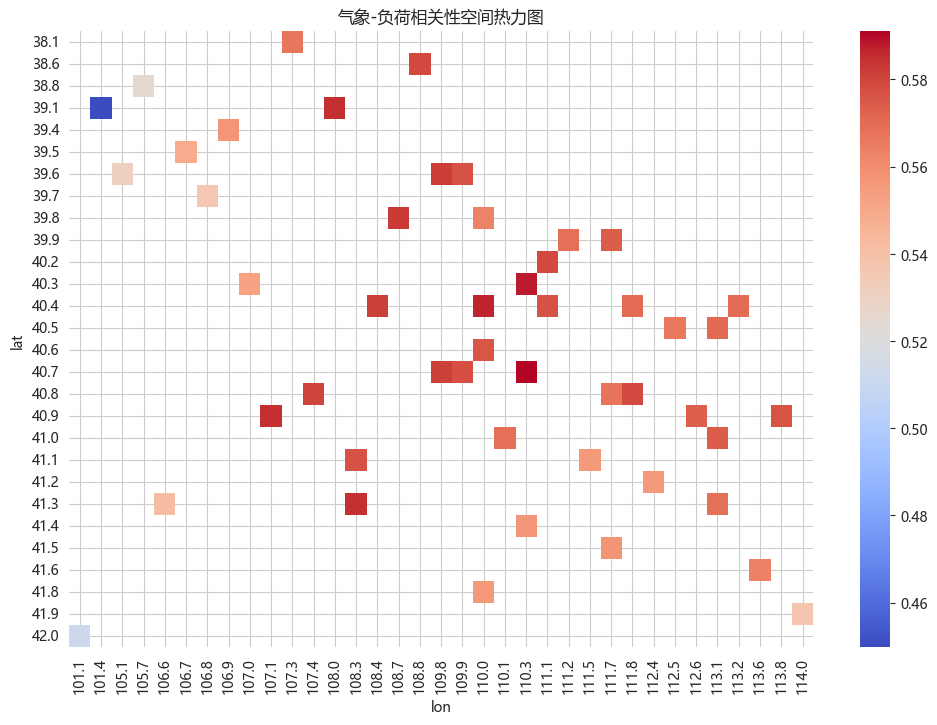

In [349]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_spatial_heatmap(df_corr):
    pivot = df_corr.pivot_table(index="lat", columns="lon", values="max_abs_corr")
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot, cmap="coolwarm", annot=False)
    plt.title("气象-负荷相关性空间热力图")
    plt.show()
df_corr["max_abs_corr"] = df_corr[
    [col for col in df_corr.columns if "pearson" in col or "spearman" in col or "kendall" in col]
].abs().max(axis=1)
plot_spatial_heatmap(df_corr)

In [267]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 根据你机器上的字体调整路径
font_path = r"C:\Windows\Fonts\msyh.ttc"  # 微软雅黑
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False


In [268]:
import numpy as np

corr_cols = [c for c in df_corr.columns if "pearson" in c or "spearman" in c or "kendall" in c]

df_corr["max_abs_corr"] = df_corr[corr_cols].abs().max(axis=1)
df_corr["dominant_var"] = df_corr[corr_cols].abs().idxmax(axis=1)

In [269]:
from scipy.interpolate import Rbf
import numpy as np

def rbf_interpolate(df_corr, value_col="max_abs_corr", grid_size=200, function="cubic"):
    lon = df_corr["lon"].values
    lat = df_corr["lat"].values
    val = df_corr[value_col].values

    # 构建 RBF 模型
    rbf = Rbf(lon, lat, val, function=function)

    # 构建规则网格
    lon_lin = np.linspace(lon.min(), lon.max(), grid_size)
    lat_lin = np.linspace(lat.min(), lat.max(), grid_size)
    grid_lon, grid_lat = np.meshgrid(lon_lin, lat_lin)

    # 插值
    grid_val = rbf(grid_lon, grid_lat)

    return grid_lon, grid_lat, grid_val


In [270]:
import matplotlib.pyplot as plt

def plot_rbf_heatmap(df_corr, value_col="max_abs_corr", function="linear", grid_size=200):
    grid_lon, grid_lat, grid_val = rbf_interpolate(
        df_corr, value_col=value_col, grid_size=grid_size, function=function
    )

    plt.figure(figsize=(10, 8))
    plt.pcolormesh(grid_lon, grid_lat, grid_val, cmap="coolwarm", shading="auto")
    cbar = plt.colorbar()
    cbar.set_label(value_col)

    # 叠加散点
    plt.scatter(df_corr["lon"], df_corr["lat"], c=df_corr[value_col],
                cmap="coolwarm", edgecolors="black", s=50)

    plt.xlabel("经度")
    plt.ylabel("纬度")
    plt.title(f"{value_col} 空间影响强度（RBF 插值）")
    plt.tight_layout()
    plt.show()


In [271]:
from pykrige.ok import OrdinaryKriging

def kriging_interpolate(df_corr, value_col="max_abs_corr", grid_size=200):
    lon = df_corr["lon"].values
    lat = df_corr["lat"].values
    val = df_corr[value_col].values

    OK = OrdinaryKriging(lon, lat, val, variogram_model="spherical")

    lon_lin = np.linspace(lon.min(), lon.max(), grid_size)
    lat_lin = np.linspace(lat.min(), lat.max(), grid_size)

    grid_val, _ = OK.execute("grid", lon_lin, lat_lin)

    grid_lon, grid_lat = np.meshgrid(lon_lin, lat_lin)
    return grid_lon, grid_lat, grid_val


In [272]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

def run_clustering(df_corr, method="kmeans", n_clusters=4):
    metric_cols = [c for c in df_corr.columns if "pearson" in c]
    X = df_corr[metric_cols].fillna(0).values
    X_scaled = StandardScaler().fit_transform(X)

    df_res = df_corr.copy()

    if method == "kmeans":
        km = KMeans(n_clusters=n_clusters, n_init="auto")
        labels = km.fit_predict(X_scaled)
        df_res["cluster"] = labels
        return df_res

    if method == "dbscan":
        db = DBSCAN(eps=0.7, min_samples=3)
        labels = db.fit_predict(X_scaled)
        df_res["cluster"] = labels
        return df_res


In [273]:
def plot_cluster_map(df_corr, cluster_col="cluster"):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(df_corr["lon"], df_corr["lat"], c=df_corr[cluster_col],
                          cmap="tab10", s=50)
    plt.colorbar(scatter)
    plt.xlabel("经度")
    plt.ylabel("纬度")
    plt.title("气象-负荷相关性区域聚类")
    plt.show()


In [274]:
sensitive = df_corr[df_corr["max_abs_corr"] > 0.4]
print("敏感区域：")
print(sensitive[["lat", "lon", "max_abs_corr", "dominant_var"]])

敏感区域：
Empty DataFrame
Columns: [lat, lon, max_abs_corr, dominant_var]
Index: []


In [275]:
top20 = df_corr.sort_values("max_abs_corr", ascending=False).head(20)
print(top20)

     lat    lon  rh_pearson  rh_spearman  rh_kendall  t_avg_pearson  \
47  50.2  120.2    0.389333     0.373074    0.249277       0.188078   
48  50.8  121.5    0.379996     0.387374    0.265988       0.208621   
22  41.9  118.7    0.369926     0.376236    0.256235       0.223848   
96  44.1  123.2    0.332746     0.337880    0.228190       0.171738   
57  40.9  113.8    0.321142     0.323501    0.213144       0.209182   
53  41.0  113.1    0.261422     0.268781    0.178919       0.203660   
54  40.9  112.6    0.282576     0.292593    0.198564       0.209708   
94  40.5  113.1    0.284015     0.286643    0.195286       0.211430   
74  42.0  101.1    0.066535     0.136587    0.074409       0.215000   
72  42.2  116.5    0.297940     0.310093    0.208016       0.211236   
60  40.4  113.2    0.299053     0.304729    0.208468       0.214262   
25  43.6  122.3    0.309562     0.323785    0.216938       0.181697   
83  50.4  123.4    0.302949     0.323668    0.218691       0.191017   
23  41

In [350]:
def build_sensitivity_score(df_corr, factors=["rh","t_avg","ssrd","ws","wd"]):
    df = df_corr.copy()
    for f in factors:
        df[f"{f}_score"] = df[[f"{f}_pearson",f"{f}_spearman",f"{f}_kendall"]].abs().mean(axis=1)
    df["total_score"] = df[[f"{f}_score" for f in factors]].mean(axis=1)
    return df
def cluster_and_select(df_top, k=8):
    coords = df_top[["lat","lon"]].values
    kmeans = KMeans(n_clusters=k, random_state=42)
    df_top["cluster"] = kmeans.fit_predict(coords)

    selected = []
    for cid, dfc in df_top.groupby("cluster"):
        # 每个 cluster 挑选最敏感的一个格点
        best = dfc.sort_values("total_score", ascending=False).head(1)
        selected.append(best)

    df_selected = pd.concat(selected, ignore_index=True)
    return df_selected
df_scored = build_sensitivity_score(df_corr)
df_top = df_scored.sort_values("total_score", ascending=False).head(200)
df_selected = cluster_and_select(df_top, k=8)

print(df_selected)


    lat    lon  rh_pearson  rh_spearman  rh_kendall  t_avg_pearson  \
0  38.1  107.3    0.387136     0.396676    0.270577       0.353503   
1  40.8  111.8    0.363854     0.423770    0.281533       0.353066   
2  42.0  101.1    0.208718     0.260827    0.167774       0.314770   
3  39.6  109.8    0.458361     0.467764    0.317736       0.367687   
4  41.1  108.3    0.337577     0.327085    0.221374       0.338720   
5  39.4  106.9    0.370926     0.389629    0.266569       0.339938   
6  40.5  113.1    0.409220     0.420606    0.289565       0.341122   
7  40.7  110.3    0.504082     0.513244    0.356202       0.409702   

   t_avg_spearman  t_avg_kendall  ssrd_pearson  ssrd_spearman  ...  \
0        0.567102       0.393216      0.339250       0.418854  ...   
1        0.578975       0.406475      0.336868       0.393146  ...   
2        0.511888       0.347199      0.372044       0.442488  ...   
3        0.581757       0.405751      0.343777       0.406481  ...   
4        0.576856  

In [277]:
from sklearn.linear_model import LinearRegression
def build_regression_factor(df_weather, df_load, df_selected, factor):
    # 1）仅保留被选定格点的数据
    df_sub = df_weather.merge(
        df_selected[["lat","lon"]],
        on=["lat","lon"],
        how="inner"
    )

    # 2）展开成列：datetime × 多格点
    df_w = df_sub.pivot_table(index="datetime", columns="lat", values=factor)
    df_w = df_w.sort_index().fillna(method="ffill").fillna(method="bfill")

    # 3）与负荷合并
    df_m = df_w.merge(df_load.set_index("datetime"), left_index=True, right_index=True)

    X = df_m[df_w.columns].values
    y = df_m["load"].values

    # 4）线性回归求权重
    model = LinearRegression(positive=True)
    model.fit(X, y)
    w = model.coef_ / model.coef_.sum()

    # 5）合成气象因子
    df_out = df_w.values.dot(w)

    return pd.Series(df_out, index=df_w.index, name=f"{factor}_eff")
factors = ["t_avg","rh","ssrd","ws","wd"]
eff_features = {}

for f in factors:
    eff_features[f"{f}_eff"] = build_regression_factor(
        df_weather, df_load_, df_selected, f
    )
df_eff = pd.concat(eff_features.values(), axis=1)
print(df_eff.head())


                     t_avg_eff  rh_eff  ssrd_eff    ws_eff      wd_eff
datetime                                                              
2024-01-01 00:00:00      -10.8     NaN       0.0  1.612802   92.912189
2024-01-01 01:00:00      -11.2     NaN       0.0  1.612802   92.912189
2024-01-01 02:00:00      -10.4     NaN       0.0  1.331606   96.964714
2024-01-01 03:00:00      -11.4     NaN       0.0  1.256810  199.092926
2024-01-01 04:00:00      -12.5     NaN       0.0  1.292765  225.511893


C:\Users\18333\AppData\Local\Temp\ipykernel_29788\4236948255.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_w = df_w.sort_index().fillna(method="ffill").fillna(method="bfill")
C:\Users\18333\AppData\Local\Temp\ipykernel_29788\4236948255.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_w = df_w.sort_index().fillna(method="ffill").fillna(method="bfill")
C:\Users\18333\AppData\Local\Temp\ipykernel_29788\4236948255.py:23: RuntimeWarning: invalid value encountered in divide
  w = model.coef_ / model.coef_.sum()
C:\Users\18333\AppData\Local\Temp\ipykernel_29788\4236948255.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_w = df_w.sort_index().fillna(method="ffill").fillna(method="bfill")
C:\Users\18

In [351]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

def spatial_join_nearest(df_points, df_corr):
    """
    df_points: 需要权重的城镇点（areacode, lat, lon）
    df_corr:   每个格点的相关性结果（lat, lon, t_avg_pearson 等）
    """

    coords_points = df_points[['lat', 'lon']].values
    coords_corr = df_corr[['lat', 'lon']].values

    nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(coords_corr)
    distances, indices = nbrs.kneighbors(coords_points)

    df_points = df_points.copy()
    df_points['nearest_idx'] = indices.flatten()

    df_merge = df_points.join(
        df_corr.iloc[indices.flatten()].reset_index(drop=True),
        rsuffix="_corr"
    )

    return df_merge
def compute_weights(df_merged,
                    w_temp=0.40, w_ws=0.25, w_rh=0.20, w_ssrd=0.15):
    """
    输入：df_merged = 城镇点 + 最近格点相关性
    输出：各点 score + weight
    """

    df = df_merged.copy()

    df["score"] = (
        w_temp * df["t_avg_pearson"].abs()
        + w_ws   * df["ws_pearson"].abs()
        + w_rh   * df["rh_pearson"].abs()
        + w_ssrd * df["ssrd_pearson"].abs()
    )

    df["weight"] = df["score"] / df["score"].sum()

    return df[["areacode", "lat", "lon", "score", "weight"]]


In [352]:
# 最近邻匹配
df_merged = spatial_join_nearest(df_, df_corr)

# 计算权重
df_weights = compute_weights(df_merged)

print(df_weights.head())



    areacode   lat    lon     score    weight
0  101080108  40.8  111.7  0.306978  0.036027
1  101080109  40.8  111.7  0.306978  0.036027
2  101080110  40.8  111.7  0.306978  0.036027
3  101080106  40.8  111.7  0.306978  0.036027
4  101080103  40.2  111.1  0.320459  0.037609


In [280]:
from sklearn.cluster import KMeans
import pandas as pd

def cluster_corr_points(df_corr, n_clusters=10):
    coords = df_corr[['lat', 'lon']].values

    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(coords)
    df_corr['cluster'] = kmeans.labels_

    centers = pd.DataFrame(kmeans.cluster_centers_, columns=['lat', 'lon'])
    centers['cluster'] = centers.index

    return df_corr, centers
from sklearn.neighbors import NearestNeighbors

def match_points_to_centers(df_points, centers):
    coords_points = df_points[['lat', 'lon']].values
    coords_centers = centers[['lat', 'lon']].values

    nbrs = NearestNeighbors(n_neighbors=1).fit(coords_centers)
    _, idx = nbrs.kneighbors(coords_points)

    df_points = df_points.copy()
    df_points['cluster'] = idx.flatten()
    return df_points
def compute_cluster_weights(df_corr, df_points,
                            w_temp=0.4, w_ws=0.25, w_rh=0.2, w_ssrd=0.15):

    df_scores = (
        df_corr.groupby("cluster")
        .apply(lambda g: (
            w_temp * g["t_avg_pearson"].abs().mean() +
            w_ws   * g["ws_pearson"].abs().mean() +
            w_rh   * g["rh_pearson"].abs().mean() +
            w_ssrd * g["ssrd_pearson"].abs().mean()
        ))
        .reset_index(name="score")
    )

    df_scores["weight"] = df_scores["score"] / df_scores["score"].sum()

    # 合并回城镇点
    df_out = df_points.merge(df_scores, on="cluster", how="left")

    return df_out
# 1. 聚类格点（df_corr 为你的相关性结果）
df_corr2, centers = cluster_corr_points(df_corr, n_clusters=10)

# 2. 城镇匹配聚类中心（df_ 为你的 areacode+lat+lon）
df_points2 = match_points_to_centers(df_, centers)

# 3. 计算最终权重
df_weights = compute_cluster_weights(df_corr2, df_points2)

print(df_weights.head())
print("权重和 =", df_weights["weight"].sum())


    areacode   lat    lon  cluster     score    weight
0  101080108  40.8  111.7        7  0.200925  0.108594
1  101080109  40.8  111.7        7  0.200925  0.108594
2  101080110  40.8  111.7        7  0.200925  0.108594
3  101080106  40.8  111.7        7  0.200925  0.108594
4  101080103  40.2  111.1        8  0.190791  0.103117
权重和 = 11.56686693465217


C:\Users\18333\AppData\Local\Temp\ipykernel_29788\2165991164.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (


In [281]:
print(df_weights)

      areacode   lat    lon  cluster     score    weight
0    101080108  40.8  111.7        7  0.200925  0.108594
1    101080109  40.8  111.7        7  0.200925  0.108594
2    101080110  40.8  111.7        7  0.200925  0.108594
3    101080106  40.8  111.7        7  0.200925  0.108594
4    101080103  40.2  111.1        8  0.190791  0.103117
..         ...   ...    ...      ...       ...       ...
110  101080503  44.1  123.2        1  0.167121  0.090324
111  101080504  42.6  122.2        4  0.179295  0.096904
112  101080603  43.5  120.0        4  0.179295  0.096904
113  101081202  39.1  101.4        5  0.192827  0.104218
114  101081201  39.6  105.1        9  0.160227  0.086598

[115 rows x 6 columns]


In [282]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

def select_top_centers(df_corr, n_centers=10):
    """
    df_corr 需要包含：
    lat, lon, rh_pearson, t_avg_pearson, ssrd_pearson, ws_pearson 等

    返回：
        df_centers: 10 个格点 + 各自 score
    """

    # 定义相关性打分（可根据你的需求微调权重）
    df_corr = df_corr.copy()
    df_corr["score"] = (
        df_corr["t_avg_pearson"].abs() * 0.40 +
        df_corr["ws_pearson"].abs()    * 0.25 +
        df_corr["rh_pearson"].abs()    * 0.20 +
        df_corr["ssrd_pearson"].abs()  * 0.15
    )

    # 聚类 10 组
    coords = df_corr[["lat", "lon"]].values
    kmeans = KMeans(n_clusters=n_centers, random_state=42).fit(coords)
    df_corr["cluster"] = kmeans.labels_

    # 选每个 cluster 中 score 最高的点作为中心格点
    centers = (df_corr
               .sort_values("score", ascending=False)
               .groupby("cluster")
               .head(1)
               .reset_index(drop=True))

    return centers
def compute_weights_for_centers(df_centers):
    df = df_centers.copy()
    df["weight"] = df["score"] / df["score"].sum()
    return df
# 1. 选出 10 个气象中心格点
df_centers = select_top_centers(df_corr, n_centers=10)

# 2. 计算 10 个格点的权重（总和 = 1）
df_weights = compute_weights_for_centers(df_centers)

print(df_weights)
print("权重和 =", df_weights["weight"].sum())


    lat    lon  rh_pearson  rh_spearman  rh_kendall  t_avg_pearson  \
0  50.2  120.2    0.389333     0.373074    0.249277       0.188078   
1  41.9  115.3    0.287678     0.294257    0.193355       0.200569   
2  40.9  113.8    0.321142     0.323501    0.213144       0.209182   
3  40.7  110.3    0.287321     0.310004    0.207038       0.244320   
4  41.9  118.7    0.369926     0.376236    0.256235       0.223848   
5  43.6  122.3    0.309562     0.323785    0.216938       0.181697   
6  40.9  107.1    0.212029     0.230367    0.150707       0.207738   
7  42.0  101.1    0.066535     0.136587    0.074409       0.215000   
8  39.4  106.9    0.192356     0.208593    0.137208       0.207245   
9  48.1  118.2    0.186701     0.145444    0.091071       0.174896   

   t_avg_spearman  t_avg_kendall  ssrd_pearson  ssrd_spearman  ...  \
0        0.316707       0.207283      0.313472       0.254284  ...   
1        0.321131       0.217738      0.300838       0.249103  ...   
2        0.336342  

In [293]:
df_city = df[[
    "areacode", "province_geocode", "province",
    "city_geocode", "city", "district_geocode", "district",
    "lon", "lat"
]].dropna()

In [305]:
from sklearn.cluster import KMeans

def select_top_centers(df_corr, n_centers=10):
    df_corr = df_corr.copy()

    df_corr["score"] = (
        df_corr["t_avg_pearson"].abs() * 0.50 +
        df_corr["ws_pearson"].abs()    * 0.25 +
        df_corr["rh_pearson"].abs()    * 0.10 +
        df_corr["ssrd_pearson"].abs()  * 0.15
    )

    coords = df_corr[["lat", "lon"]].values
    kmeans = KMeans(n_clusters=n_centers, random_state=42).fit(coords)
    df_corr["cluster"] = kmeans.labels_

    centers = (
        df_corr.sort_values("score", ascending=False)
               .groupby("cluster")
               .head(1)
               .reset_index(drop=True)
    )

    return centers


In [306]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

def match_centers_to_city(df_centers, df_city):
    centers = df_centers.copy()

    nbrs = NearestNeighbors(n_neighbors=1, algorithm="ball_tree").fit(
        df_city[["lat","lon"]]
    )

    dists, idx = nbrs.kneighbors(centers[["lat","lon"]])

    match = df_city.iloc[idx.flatten()].reset_index(drop=True)

    result = pd.concat([centers.reset_index(drop=True), match], axis=1)
    result["match_distance_deg"] = dists.flatten()

    return result
def compute_weights(df_matched):
    df = df_matched.copy()
    df["weight"] = df["score"] / df["score"].sum()
    return df


In [357]:
# 1. 从 df_corr 选取代表性格点
df_corr=df_corr.sort_values("max_abs_corr", ascending=False)
# print(df_corr.head(10))
# print(df_corr.columns)
df_centers = select_top_centers(df_corr, n_centers=5)

# 2. 匹配城市编码表
df_matched = match_centers_to_city(df_centers, df_city)

# 3. 计算权重
df_final = compute_weights(df_matched)
df_final['weight'] = df_final['weight'].round(2)
print(df_final.sort_values('weight', ascending=False))
# print("权重和 =", df_final["weight"].sum())


    areacode   lat        lat    lon         lon     score  weight
0  101080211  40.7  40.672094  110.3  110.272565  0.381694    0.24
1  101080406  40.9  40.872437  113.8  113.834009  0.338071    0.21
2  101080705  38.1  38.110000  107.3  107.290000  0.319390    0.20
3  101080303  39.4  39.441530  106.9  106.884789  0.307247    0.19
4  101081203  42.0  41.958813  101.1  101.069440  0.268234    0.17


In [318]:
print(df_final.columns)

Index(['lat', 'lon', 'rh_pearson', 'rh_spearman', 'rh_kendall',
       't_avg_pearson', 't_avg_spearman', 't_avg_kendall', 'ssrd_pearson',
       'ssrd_spearman', 'ssrd_kendall', 'wd_pearson', 'wd_spearman',
       'wd_kendall', 'ws_pearson', 'ws_spearman', 'ws_kendall', 'max_abs_corr',
       'dominant_var', 'cluster', 'score', 'areacode', 'province_geocode',
       'province', 'city_geocode', 'city', 'district_geocode', 'district',
       'lon', 'lat', 'match_distance_deg', 'weight'],
      dtype='object')


In [316]:
print(df_final[['areacode','weight','lon', 'lat']].sort_values('weight', ascending=False))

    areacode    weight    lon         lon   lat        lat
0  101080911  0.110981  115.3  115.287280  41.9  41.895199
1  101080406  0.108873  113.8  113.834009  40.9  40.872437
2  101080211  0.108281  110.3  110.272565  40.7  40.672094
3  101081014  0.107425  120.2  120.178636  50.2  50.243900
4  101081015  0.107143  121.5  121.532724  50.8  50.780454
5  101081203  0.097572  101.1  101.069440  42.0  41.958813
6  101080810  0.096278  107.1  107.147682  40.9  40.888797
7  101080611  0.093057  118.7  118.708572  41.9  41.927780
8  101080501  0.090823  122.3  122.263119  43.6  43.617429
9  101080910  0.079568  117.4  117.360000  44.4  44.350000
